### **CUSTOM CNN (REAL ONLY) VS CUSTOM CNN (REAL+SYNTHETIC)**

#### **Why Balanced Accuracy and Matthews Correlation Coefficient are better than F1 score for imbalanced datasets ?**
♦ F1 score may be misleading for heavily imbalanced datasets as it's biased towards the majority class due to equal weighting of precision and recall, regardless of class balance. Thus, a high F1 score does not necessarily indicate good performance on the minority class.

♦ F1 score is insensitive to misclassified true negatives and prioritizes positive instances more as both precision and recall are calculated based on the positive instances. When working on a heavily imbalanced dataset where positives are as important as the negatives, Balanced Accuracy does much better than F1 score because balanced accuracy shows a fast decrease when there is a decrease in the correct predictions of true negatives.

♦ Matthew’s correlation coefficient takes into account all four categories of confusion matrix and scores high only if high percentage of both negative and positive instances are classified correctly, regardless of class balance or imbalance. It's unbiased towards any class and hence suitable for heavily imbalanced datasets.

♦ Confusion matrix will enable the researcher to compare the performance on the minority classes for testing the hypothesis of this research.

In [2]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from pathlib import Path
import tensorflow as tf
from random import randint
from tensorflow import keras
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from keras.utils.vis_utils import plot_model
from tensorflow.keras import Sequential, Input
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv2D, Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef as MCC
from distutils.dir_util import copy_tree, remove_tree
from sklearn.metrics import balanced_accuracy_score as BAS
from tensorflow.keras.applications.resnet50 import ResNet50 
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.densenet import DenseNet169
from tensorflow.keras.applications.inception_v3 import InceptionV3
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.efficientnet import EfficientNetB3
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IDG
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization, MaxPool2D, GlobalAveragePooling2D

In [5]:
tf.random.set_seed(5638)
random.seed(5638)

In [6]:
EPOCHS = 100
BATCH_SIZE = 32
IMG_SIZE = 128
IMAGE_SIZE = [128, 128]
DIM = (IMG_SIZE, IMG_SIZE)

In [7]:
train_dir = Path('/kaggle/input/combined-dataset/Combined Dataset/train/')

# Get filepaths and labels
filepaths = list(train_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
train_df = pd.concat([filepaths, labels], axis=1)

# Shuffle the DataFrame and reset index
train_df = train_df.sample(frac=1).reset_index(drop = True)

# Show the result
train_df.head(3)

,Filepath,Label
0,Combined Dataset\train\Very Mild Impairment\Ve...,Very Mild Impairment
1,Combined Dataset\train\Moderate Impairment\Mod...,Moderate Impairment
2,Combined Dataset\train\Moderate Impairment\Mod...,Moderate Impairment


In [8]:
test_dir = Path('/kaggle/input/kaggle-alzheimers-dataset/Kaggle Alzheimers Dataset/test/')

# Get filepaths and labels
filepaths = list(test_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
test_df = pd.concat([filepaths, labels], axis=1)

# Shuffle the DataFrame and reset index
test_df = test_df.sample(frac=1).reset_index(drop = True)

# Show the result
test_df.head(3)

,Filepath,Label
0,Kaggle Alzheimers Dataset\test\NoImpairment\28...,NoImpairment
1,Kaggle Alzheimers Dataset\test\NoImpairment\3 ...,NoImpairment
2,Kaggle Alzheimers Dataset\test\NoImpairment\28...,NoImpairment


In [9]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.0)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1.0/255.0)

train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(128,128),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    seed = 5638,
    shuffle=False
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(128, 128),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    seed = 5638,
    shuffle=False
)

CLASSES = list(test_images.class_indices.keys())

Found 10240 validated image filenames belonging to 4 classes.
Found 1279 validated image filenames belonging to 4 classes.


### **CUSTOM CNN (REAL ONLY)**

In [10]:
custom_cnn_real = tf.keras.models.load_model('./custom_cnn_(real only)_(87.04%).h5')
custom_cnn_real.summary(line_length=100)

Model: "cnn_model"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 conv2d_27 (Conv2D)                          (None, 128, 128, 16)                    448            
                                                                                                    
 conv2d_28 (Conv2D)                          (None, 128, 128, 16)                    2320           
                                                                                                    
 max_pooling2d_15 (MaxPooling2D)             (None, 64, 64, 16)                      0              
                                                                                                    
 conv2d_29 (Conv2D)                          (None, 64, 64, 32)                      4640           
                                                                        

In [11]:
test_scores = custom_cnn_real.evaluate(test_images)
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))
pred_labels = custom_cnn_real.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)

pred = np.argmax(pred_labels,axis=1)

print(classification_report(test_images.classes,pred,target_names=CLASSES))

40/40 [==============================] - 10s 223ms/step - loss: 0.4526 - acc: 0.8913 - auc: 0.9710 - f1_score: 0.8802
Testing Accuracy: 89.13%
40/40 [==============================] - 9s 216ms/step
                    precision    recall  f1-score   support

    MildImpairment       1.00      0.65      0.79       179
ModerateImpairment       0.86      1.00      0.92        12
      NoImpairment       0.83      1.00      0.91       640
VeryMildImpairment       0.99      0.83      0.90       448

          accuracy                           0.89      1279
         macro avg       0.92      0.87      0.88      1279
      weighted avg       0.91      0.89      0.89      1279



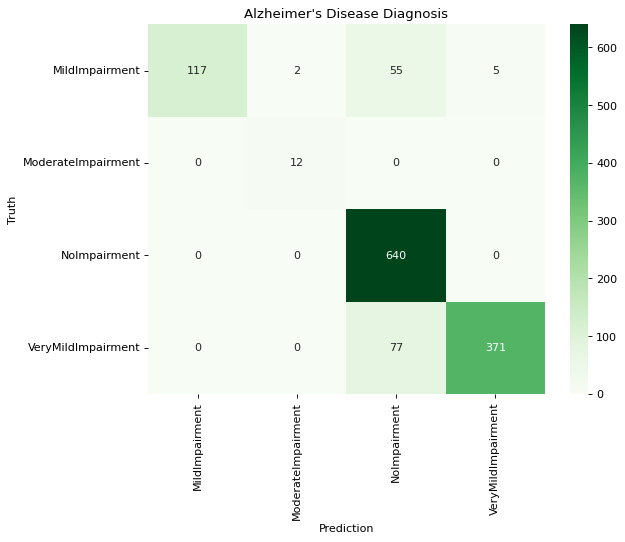

In [12]:
# Plot the confusion matrix to understand the classification in detail

test_ls, pred_ls = test_images.classes,pred
conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [13]:
#Printing some other classification metrics
print("Balanced Accuracy Score: {} %".format(round(BAS(test_ls, pred_ls) * 100, 2)))
print("Matthew's Correlation Coefficient: {} %".format(round(MCC(test_ls, pred_ls) * 100, 2)))

Balanced Accuracy Score: 87.04 %
Matthew's Correlation Coefficient: 82.61 %


### **CUSTOM CNN (REAL + SYNTHETIC)**

In [14]:
custom_model_combined = Sequential([
    Input(shape=(*IMAGE_SIZE, 3)),
    Conv2D(16, 3, activation='relu', padding='same'),
    Conv2D(16, 3, activation='relu', padding='same'),
    MaxPool2D(),
    Conv2D(32, 3, activation='relu', padding='same'),
    Conv2D(32, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),
    Conv2D(64, 3, activation='relu', padding='same'),
    Conv2D(64, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),
    Conv2D(128, 3, activation='relu', padding='same'),
    Conv2D(128, 3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(),
    Conv2D(256, 3, activation='relu', padding='same'),
    Conv2D(256, 3, activation='relu', padding='same', name = 'last_conv_layer'),
    BatchNormalization(),
    MaxPool2D(),
    Flatten(),
    Dropout(0.2),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.7),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(4, activation='softmax')        
], name = "cnn_model")

custom_model_combined.summary(line_length=100)

Model: "cnn_model"
____________________________________________________________________________________________________
 Layer (type)                                Output Shape                            Param #        
 conv2d (Conv2D)                             (None, 128, 128, 16)                    448            
                                                                                                    
 conv2d_1 (Conv2D)                           (None, 128, 128, 16)                    2320           
                                                                                                    
 max_pooling2d (MaxPooling2D)                (None, 64, 64, 16)                      0              
                                                                                                    
 conv2d_2 (Conv2D)                           (None, 64, 64, 32)                      4640           
                                                                        

In [51]:
OPT = tf.keras.optimizers.Adam(learning_rate=0.001)

METRICS = [tf.keras.metrics.CategoricalAccuracy(name='acc'),
           tf.keras.metrics.AUC(name='auc'), 
           tfa.metrics.F1Score(num_classes=4)]

custom_model_combined.compile(optimizer='adam',
                              loss=tf.losses.CategoricalCrossentropy(),
                              metrics=METRICS)

In [66]:
earlystopping = EarlyStopping(monitor = 'val_loss', 
                              mode = 'min', 
                              patience = 10,
                              verbose = 1)

filepath = './best_weights.hdf5'

checkpoint    = ModelCheckpoint(filepath, 
                                monitor = 'val_loss', 
                                mode='min', 
                                save_best_only=True, 
                                verbose = 1)


callback_list = [earlystopping, checkpoint]

In [67]:
#Fit the training data to the model and validate it using the validation data
custom_model_combined_history = custom_model_combined.fit(train_images,validation_data=test_images, callbacks=callback_list, epochs=EPOCHS)

Epoch 1/100
320/320 [==============================] - ETA: 0s - loss: 3.3777e-04 - acc: 1.0000 - auc: 1.0000 - f1_score: 1.0000
Epoch 1: val_loss improved from inf to 0.08673, saving model to ./best_weights.hdf5
320/320 [==============================] - 18s 57ms/step - loss: 3.3777e-04 - acc: 1.0000 - auc: 1.0000 - f1_score: 1.0000 - val_loss: 0.0867 - val_acc: 0.9812 - val_auc: 0.9947 - val_f1_score: 0.9866
Epoch 2/100
319/320 [============================>.] - ETA: 0s - loss: 2.0965e-04 - acc: 1.0000 - auc: 1.0000 - f1_score: 1.0000
Epoch 2: val_loss did not improve from 0.08673
320/320 [==============================] - 17s 54ms/step - loss: 2.0905e-04 - acc: 1.0000 - auc: 1.0000 - f1_score: 1.0000 - val_loss: 0.1013 - val_acc: 0.9820 - val_auc: 0.9932 - val_f1_score: 0.9881
Epoch 3/100
320/320 [==============================] - ETA: 0s - loss: 1.7830e-04 - acc: 1.0000 - auc: 1.0000 - f1_score: 1.0000
Epoch 3: val_loss did not improve from 0.08673
320/320 [========================

In [68]:
test_scores = custom_model_combined.evaluate(test_images)
print("Testing Accuracy: %.2f%%"%(test_scores[1] * 100))
pred_labels = custom_model_combined.predict(test_images)

def roundoff(arr):
    """To round off according to the argmax of each predicted label array."""
    arr[np.argwhere(arr != arr.max())] = 0
    arr[np.argwhere(arr == arr.max())] = 1
    return arr

for labels in pred_labels:
    labels = roundoff(labels)
    
pred = np.argmax(pred_labels,axis=1)

print(classification_report(test_images.classes,pred,target_names=CLASSES))

40/40 [==============================] - 2s 44ms/step - loss: 0.1300 - acc: 0.9797 - auc: 0.9926 - f1_score: 0.9852
Testing Accuracy: 97.97%
40/40 [==============================] - 2s 44ms/step
                    precision    recall  f1-score   support

    MildImpairment       0.99      0.98      0.99       179
ModerateImpairment       1.00      1.00      1.00        12
      NoImpairment       0.97      1.00      0.98       640
VeryMildImpairment       0.99      0.95      0.97       448

          accuracy                           0.98      1279
         macro avg       0.99      0.98      0.99      1279
      weighted avg       0.98      0.98      0.98      1279



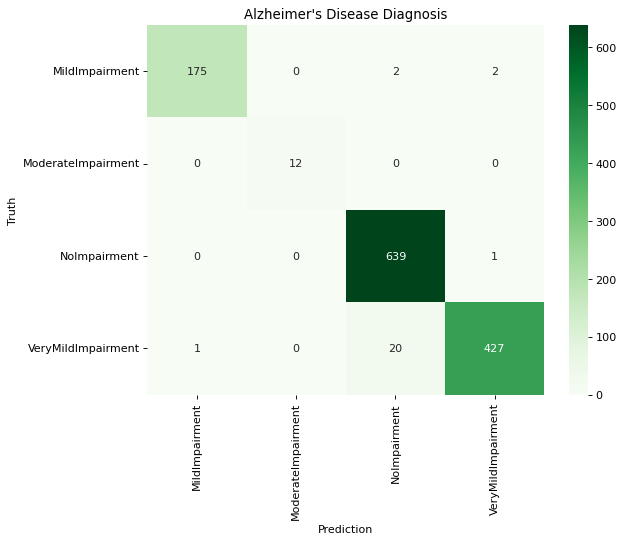

In [69]:
# Plot the confusion matrix to understand the classification in detail

test_ls, pred_ls = test_images.classes,pred
conf_arr = confusion_matrix(test_ls, pred_ls)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')

ax = sns.heatmap(conf_arr, cmap='Greens', annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)

plt.title('Alzheimer\'s Disease Diagnosis')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [71]:
#Printing some other classification metrics
print("Balanced Accuracy Score: {} %".format(round(BAS(test_ls, pred_ls) * 100, 2)))
print("Matthew's Correlation Coefficient: {} %".format(round(MCC(test_ls, pred_ls) * 100, 2)))

Balanced Accuracy Score: 98.81 %
Matthew's Correlation Coefficient: 97.56 %


In [72]:
custom_model_combined.save('custom_cnn_(combined)_(98.81%).h5')